<a href="https://colab.research.google.com/github/SAKINA-KHAN3821/CODSOFT/blob/main/movie_genre_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
!pip install pandas scikit-learn


In [38]:
from google.colab import files
uploaded = files.upload()


Saving test_data.txt to test_data (1).txt


In [39]:
import pandas as pd
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [40]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

In [41]:
train_data = pd.read_csv("train_data.txt", sep=":::", names=["ID","Title","Genre","Plot"], engine='python')
test_data = pd.read_csv("test_data.txt", sep=":::", names=["ID","Title","Plot"], engine='python')
solution = pd.read_csv("test_data_solution.txt", sep=":::", names=["ID","Title","Genre","Plot"], engine='python')

# Display the head of train_data to check if it's loaded correctly
print("Train Data Head after initial load:")
display(train_data.head())

# The following lines are causing the DataFrame to become empty, so I will comment them out for now.
# train_data = train_data.dropna()
# test_data = test_data.dropna()
# solution = solution.dropna()

Train Data Head after initial load:


,ID,Title,Genre,Plot
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [42]:
train_data = pd.read_csv("train_data.txt", sep=":::", names=["ID","Title","Genre","Plot"], engine='python')
test_data = pd.read_csv("test_data.txt", sep=":::", names=["ID","Title","Plot"], engine='python')
solution = pd.read_csv("test_data_solution.txt", sep=":::", names=["ID","Title","Genre","Plot"], engine='python')

print("Train Data Head after explicit load:")
display(train_data.head())

Train Data Head after explicit load:


,ID,Title,Genre,Plot
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [43]:
selected_genres = ['action', 'comedy', 'drama', 'horror'] # Convert selected genres to lowercase for consistent matching

print("Genre counts before filtering:")
print(train_data['Genre'].value_counts())

train_data['Genre'] = train_data['Genre'].str.lower().str.strip() # Convert 'Genre' column to lowercase and strip spaces
solution['Genre'] = solution['Genre'].str.lower().str.strip() # Convert 'Genre' column to lowercase and strip spaces

train_data = train_data[train_data['Genre'].isin(selected_genres)]
solution = solution[solution['Genre'].isin(selected_genres)]

# Filter test_data to only include rows corresponding to the filtered solution IDs
# This ensures that X_test is generated from test samples that we intend to evaluate.
test_data = test_data[test_data['ID'].isin(solution['ID'])]

print("\nGenre counts after filtering:")
print(train_data['Genre'].value_counts())

Genre counts before filtering:
Genre
drama           13613
documentary     13096
comedy           7447
short            5073
horror           2204
thriller         1591
action           1315
western          1032
reality-tv        884
family            784
adventure         775
music             731
romance           672
sci-fi            647
adult             590
crime             505
animation         498
sport             432
talk-show         391
fantasy           323
mystery           319
musical           277
biography         265
history           243
game-show         194
news              181
war               132
Name: count, dtype: int64

Genre counts after filtering:
Genre
drama     13613
comedy     7447
horror     2204
action     1315
Name: count, dtype: int64


In [44]:
print("Unique genres in train_data after filtering:")
print(train_data['Genre'].unique())

Unique genres in train_data after filtering:
['drama' 'comedy' 'horror' 'action']


In [45]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

train_data['Plot'] = train_data['Plot'].apply(clean_text)
test_data['Plot'] = test_data['Plot'].apply(clean_text)
solution['Plot'] = solution['Plot'].apply(clean_text)

In [46]:
# Check if the cleaned plots are empty or very short, which could lead to an empty vocabulary
print("Length of plots after cleaning (train_data):")
print(train_data['Plot'].apply(len).value_counts().sort_index().head())
print("\nNumber of empty plots in train_data:", (train_data['Plot'].apply(len) == 0).sum())

print("\nLength of plots after cleaning (test_data):")
print(test_data['Plot'].apply(len).value_counts().sort_index().head())
print("\nNumber of empty plots in test_data:", (test_data['Plot'].apply(len) == 0).sum())


Length of plots after cleaning (train_data):
Plot
41    1
47    1
69    1
72    1
74    2
Name: count, dtype: int64

Number of empty plots in train_data: 0

Length of plots after cleaning (test_data):
Plot
61    1
62    1
72    1
74    1
78    1
Name: count, dtype: int64

Number of empty plots in test_data: 0


TF-IDF

In [47]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=20000,
    ngram_range=(1,2)
)

X_train = vectorizer.fit_transform(train_data['Plot'])
X_test = vectorizer.transform(test_data['Plot'])

Train Model

In [48]:
model = LinearSVC()
model.fit(X_train, train_data['Genre'])

LinearSVC()

Prediction

In [49]:
predictions = model.predict(X_test)

Accuracy

In [50]:
y_true = solution['Genre']

print("Accuracy:", accuracy_score(y_true, predictions))
print("\nClassification Report:\n")
print(classification_report(y_true, predictions))

Accuracy: 0.7594401041666666

Classification Report:

              precision    recall  f1-score   support

      action       0.66      0.42      0.51      1314
      comedy       0.71      0.66      0.69      7446
       drama       0.78      0.86      0.82     13612
      horror       0.82      0.68      0.75      2204

    accuracy                           0.76     24576
   macro avg       0.74      0.66      0.69     24576
weighted avg       0.76      0.76      0.75     24576



### Naive Bayes Model

In [57]:
nb_model = MultinomialNB()
nb_model.fit(X_train, train_data['Genre'])

nb_predictions = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_true, nb_predictions))
print("\nNaive Bayes Classification Report:\n")
print(classification_report(y_true, nb_predictions))

Naive Bayes Accuracy: 0.6936442057291666

Naive Bayes Classification Report:

              precision    recall  f1-score   support

      action       0.88      0.03      0.06      1314
      comedy       0.78      0.46      0.58      7446
       drama       0.67      0.96      0.79     13612
      horror       0.94      0.23      0.37      2204

    accuracy                           0.69     24576
   macro avg       0.82      0.42      0.45     24576
weighted avg       0.74      0.69      0.65     24576



### Logistic Regression Model

In [52]:
lr_model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
lr_model.fit(X_train, train_data['Genre'])

lr_predictions = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_true, lr_predictions))
print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_true, lr_predictions))

Logistic Regression Accuracy: 0.7625732421875

Logistic Regression Classification Report:

              precision    recall  f1-score   support

      action       0.76      0.29      0.42      1314
      comedy       0.74      0.65      0.69      7446
       drama       0.76      0.90      0.82     13612
      horror       0.88      0.59      0.71      2204

    accuracy                           0.76     24576
   macro avg       0.79      0.61      0.66     24576
weighted avg       0.77      0.76      0.75     24576



Demo Prediction

In [56]:
sample = ["A group of friends enter a haunted house and face ghosts"]

sample_clean = [clean_text(sample[0])]
sample_vec = vectorizer.transform(sample_clean)

pred = model.predict(sample_vec)

print("Predicted Genre:", pred[0])

Predicted Genre: horror


In [55]:
def predict_genre(plot_summary):
    cleaned_summary = clean_text(plot_summary)
    vectorized_summary = vectorizer.transform([cleaned_summary])
    predicted_genre = model.predict(vectorized_summary)
    return predicted_genre[0]

# Demonstration of the new function
custom_plot = "A young wizard discovers he has magical powers and must attend a special school to learn how to control them while facing a dark lord."
predicted = predict_genre(custom_plot)
print(f"Custom Plot Summary: {custom_plot}")
print(f"Predicted Genre: {predicted}")

Custom Plot Summary: A young wizard discovers he has magical powers and must attend a special school to learn how to control them while facing a dark lord.
Predicted Genre: drama


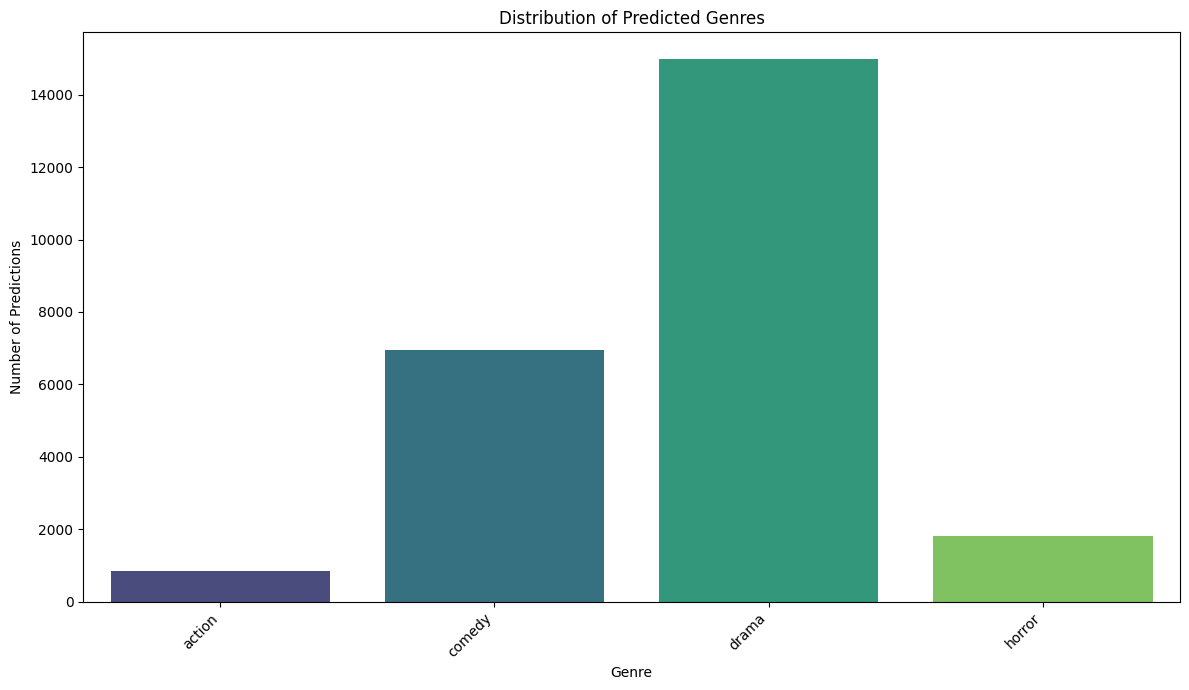

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the value counts of the predicted genres
predicted_genre_counts = pd.Series(predictions).value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x=predicted_genre_counts.index, y=predicted_genre_counts.values, hue=predicted_genre_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Predicted Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Predictions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()